# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 1: Rewriting functions...*) - Plot $f(x)$ vs. $x$ using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
    - (See Problem 2) Why do the "bad" and "good" formulas of the quadratic roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Baculo, Ezira Lojelle
- _Student No._: 2024-11845
- _Section_: THR-TX-3

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="Part 1a.png" alt="Alt text" width=45%> <img src="Part 1b.png" alt="Alt text" width=45%>


These plots show catastrophic cancellation by comparing the values from manual evaluation and algebraic manipulation. 

### Report discussion

(1) Catastrophic cancellation takes place for large positive values where $x \ge 10^{16}$ (extending up to $10^{20}$) in the first plot. Due to standard floating-point precision limits, the Manual f(x) calculation fails to maintain the theoretical limit of $0.5$ within this range, spiking erratically to $2.0$ before collapsing to $0.0$. 

On the other hand, catastrophic cancellation occurs at very small values where $x \le 10^{-15}$ in the second plot. The manual evaluation significantly deviates from the stable rewritten form as $x$ gets closer to zero, experiencing a loss of numerical precision when subtracting nearly equal quantities near zero.

(2) The "good" formula, which is entirely numerically stable, first calculates $x_-$ by adding same-signed numbers. The relation $x_+ = c / (a \cdot x_-)$ is then used to evaluate $x_+. The "good" formula fully eliminates the cancellation error and maintains full precision by substituting floating-point division for unstable subtraction.

On the other hand, The square root term $\sqrt{b^2 - 4ac}$ evaluates to a value near $b$ when $b \gg ac$. Because the "bad" formula subtracts these two almost equal large quantities in the numerator, $-b + \sqrt{b^2 - 4ac}$, it experiences catastrophic cancellation. Significant numerical error is introduced into $x_+$ by this subtraction, which eliminates the majority of important floating-point digits. 

### Other comments
- I found myself keeping up with my classmates a little bit. I'm still trying  to understand everything.
- Still finding it hard to think of innovative ways to create an algorithm, but so far, it's alright.
- Trying to plot the scatter plots was a bit tricky. I found myself searching a lot more when doing those parts of the exercise.

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Rewriting functions to avoid subtractive cancellation

#### Part 1.1: 

Consider the function $$ f(x) = \sqrt{x^2 + x} - x \tag{1}$$

(a) Start by plotting the function, using a grid of $100$ linearly-spaced points from $0$ to $100$. This should give you some idea of the values you should expect for $f(x)$ at large $x$.

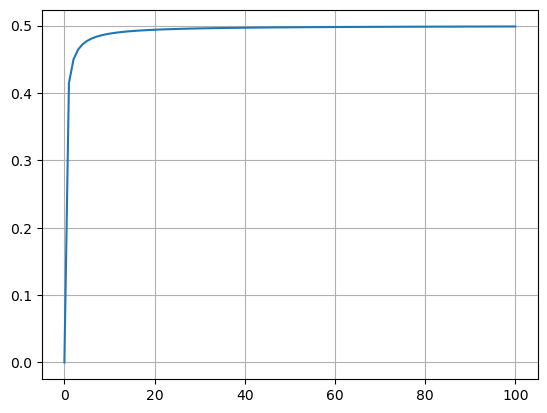

In [123]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sqrt(x**2 + x) - x

xvals = np.linspace(0, 100, 100)
yvals = f(xvals)

plt.plot(xvals, yvals)
plt.grid(True)
plt.show()

(b) Verify your previous hunch by taking the limit $x\rightarrow\infty$ and using algebraic conjugate.

$\lim_{x \to \infty} \sqrt{x^2 + x} - x \times \frac{\sqrt{x^2 + x} + x}{\sqrt{x^2 + x} + x}$

$\lim_{x \to \infty} \frac{x}{\sqrt{x^2 + x} + x}$

$\lim_{x \to \infty} \frac{x}{\sqrt{x^2(1 + \frac{1}{x})} + x}$

$\lim_{x \to \infty} \frac{1}{\sqrt{1 + \frac{1}{x}} + 1}$

$= \frac{1}{2}$ or 0.5

(c) Now, see what value you find for Eq. $(1)$ when $x = 10^{16}$. Does this make sense, even qualitatively?

In [112]:
import numpy as np

def f_worse(x):
    return np.sqrt(x**2 + x) - x

x_val = 1e16
result = f_worse(x_val)

print(f"Evaluation at x = {x_val:.1e}")
print(f"Result of f(x): {result}")
print(f"Expected result: 0.5")

Evaluation at x = 1.0e+16
Result of f(x): 2.0
Expected result: 0.5


It does not make sense, which is evident by the limit as x approaches infinity.

(d) Rewrite Eq. $(1)$ to avoid the catastrophic cancellation. Evaluate the new function at $x = 10^{16}$ and compare with your analytical answer for $x \rightarrow \infty$.

In [111]:
import numpy as np

# Using the conjugate: x / (np.sqrt(x**2 + x) + x)
def f_better(x):
    return x / (np.sqrt(x**2 + x) + x)

x_val = 1e16
result_better = f_better(x_val)

print(f"Evaluation at x = {x_val:.1e}")
print(f"Result of f(x): {result_better}")

Evaluation at x = 1.0e+16
Result of f(x): 0.5


It now aligns to the expected limit value.

(e) **[FIGURE]** Plot the $f(x)$ vs. $x$ using the manual evaluation Eq. $(1)$ vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. 

(Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

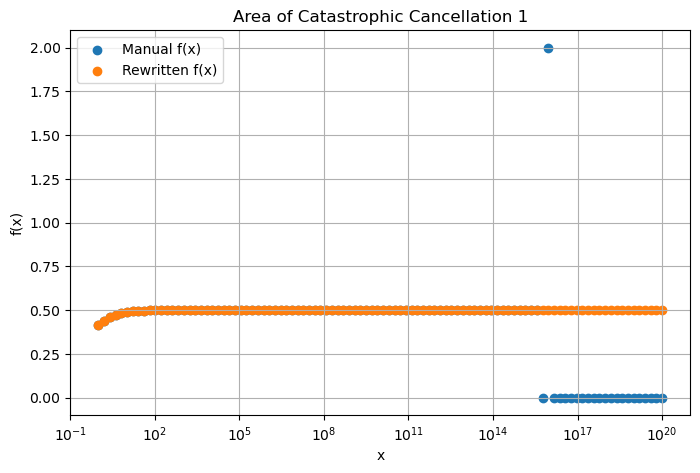

In [146]:
# template for plotting with plt.subplots()

import numpy as np
import matplotlib.pyplot as plt
import math

x = np.logspace(0, 20, 100)
f = np.sqrt(x**2 + x) - x
f_rewritten = x / (np.sqrt(x**2 + x) + x)

fig, ax = plt.subplots(figsize = (8,5))
ax.scatter(x, f, label = r'Manual f(x)')
ax.scatter(x, f_rewritten, label = r'Rewritten f(x)')
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
ax.set_xscale('log')
ax.legend()
plt.grid(True)
plt.title("Area of Catastrophic Cancellation 1")
plt.savefig("Part 1a.png", dpi=300, bbox_inches="tight")
plt.show()

#### Part 1.2: 

Consider the function 
$$ f(x) = \frac{e^x - 1}{x} \tag{2}$$

(a) Start by plotting the function, using a grid of $100$ linearly-spaced points from $0.1$ to $5.0$. This should give you some idea of the values you should expect for $f(x)$ at small $x$.

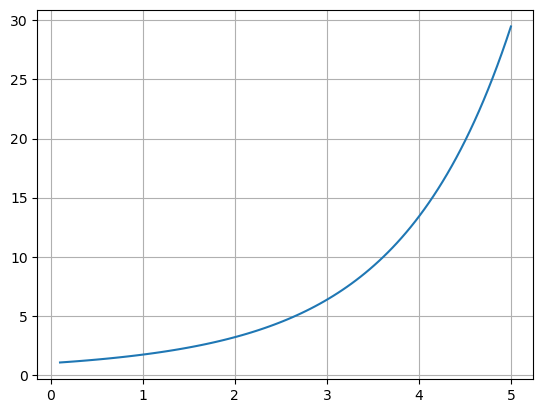

In [134]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (np.exp(x) - 1) / x

xvals = np.linspace(0.1, 5.0, 100)
yvals = f(xvals)

plt.plot(xvals, yvals)
plt.grid(True)
plt.show()

(b) Verify your previous hunch by taking the limit $x\rightarrow0$ and using L'Hôpital's rule.

$\lim_{x \to 0} f(x)$ = $ \lim_{x \to 0} \frac{d}{dx} \frac{e^x-1}{x} $ \
\
By LHR:

$\lim_{x \to 0} f(x)$ = $ \lim_{x \to 0} \frac{e^x}{1} $

$\lim_{x \to 0} f(x)$ = $1$

(c) Now, see what value you find for Eq. $(2)$ when $x = 10^{-16}$. Does this make sense, even qualitatively?

In [75]:
import numpy as np

def f_worse(x):
    return (np.exp(x) - 1) / x

x_val = 1e-16
result = f_worse(x_val)

print(f"Evaluation at x = {x_val:.1e}")
print(f"Result of f(x): {result}")
print(f"Expected result: 1.0")

Evaluation at x = 1.0e-16
Result of f(x): 0.0
Expected result: 1.0


It does not make sense, which is evident by the limit as x approaches infinity.

(d) In `NumPy`, there is a special function `np.expm1()` that evaluates $e^{x}-1$. How does the function resolve the catastrophic cancellation? Using this function, evaluate Eq. (4) at $x = 10^{-16}$ and compare with your analytical answer for $x \rightarrow 0$.

In [81]:
import numpy as np

def f_better(x):
    return np.expm1(x) / x # for very very small x

x_val = 1e-16
result_better = f_better(x_val)

print(f"Evaluation at x = {x_val:.1e}")
print(f"Result of f(x) using np.expm1: {result_better}")
print(f"Expected result: 1.0")

Evaluation at x = 1.0e-16
Result of f(x) using np.expm1: 1.0
Expected result: 1.0


It now aligns to the expected limit value.

(e) **[FIGURE]** Plot the $f(x)$ vs. $x$ using the manual evaluation Eq. $(2)$ vs. the `np.expm1()` function. In the figure, show the area where the catastrophic cancellation occurs. 

(Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

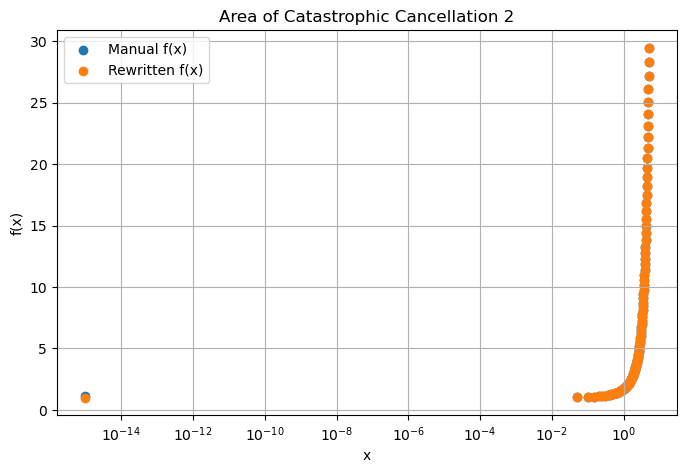

In [145]:
# template for plotting with plt.subplots()

import numpy as np
import matplotlib.pyplot as plt
import math

x = np.linspace(10e-16, 5.0, 100)
f = (np.exp(x)-1)/x
f_rewritten = np.expm1(x)/x

fig, ax = plt.subplots(figsize = (8,5))
ax.scatter(x, f, label = r'Manual f(x)')
ax.scatter(x, f_rewritten, label = r'Rewritten f(x)')
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
ax.set_xscale('log')
ax.legend()
plt.grid(True)
plt.title("Area of Catastrophic Cancellation 2")
plt.savefig("Part 1b.png", dpi=300, bbox_inches="tight")
plt.show()

#### Problem 1 code summary

These scripts examine subtractive cancellation in functions such as $x \to \infty$ for $\sqrt{x^2+x}-x$ and $x \to 0$ for $(e^x-1)/x$, where subtracting nearly equal large numbers results in precision loss. Using the algebraic conjugate method and the `np.expm1()` function, which employs a Taylor expansion to prevent catastrophic cancellation, we implemented numerically stable alternatives. The resulting plots show that even at extreme scales where standard floating-point arithmetic fails, these rewritten forms accurately preserve the analytical limits (0.5 and 1.0, respectively).

---

### Problem 2: Quadratic Equation (Gezerlis Problem 2.6)

Take the standard quadratic equation: $ax^2 + bx + c = 0$, whose solutions are:
$$
x_\pm = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a} \tag{3} 
$$ 
 

Take $b>0$ for concreteness. It is easy to see that when $b^2 \gg ac$ we don’t get
a catastrophic cancellation when evaluating $b^2 −4ac$ (we may still get a “benign”
cancellation). Furthermore, $\sqrt{b^2-4ac}\approx b$. However, this means that $x_+$ will involve
catastrophic cancellation in the numerator. We will employ an analytical trick in
order to help us preserve significant figures. Observe that the product of the two
roots obeys the relation: 

$$x_+x_−=c/a. \tag{4}$$ 

The answer now presents itself: use Eq. $(3)$ to calculate $x_−$, for which no catastrophic cancellation takes place. 
Then, use Eq. $(4)$ to calculate $x_+$. Notice that you ended up calculating $x_+$ via division only (i.e., without a catastrophic cancellation). 

Take $a = 1$, $c = 1$, and $b= 10^8$. Write a Python code that evaluates and prints out the following:

(a) $x_-$ using Eq. $(3)$

In [89]:
from math import sqrt

a, b, c = 1, 1e8, 1

x_minus = (-b - sqrt(b**2 - 4 * a * c)) / (2 * a)
print(x_minus)

-100000000.0


(b) $x_+$ using the “bad” formula -- i.e. Eq. $(3)$

In [87]:
from math import sqrt

a, b, c = 1, 1e8, 1

x_plus_bad = (-b + sqrt(b**2 -4 * a * c)) / (2 * a)
print(x_plus_bad)

-7.450580596923828e-09


(c) $x_+$ using the “good” formula -- i.e. Eq. $(4)$

In [90]:
from math import sqrt

a, b, c = 1, 1e8, 1

x_minus = (-b - sqrt(b**2 - 4 * a * c)) / (2 * a)

x_plus_good = c / (a * x_minus)
print(x_plus_good)

-1e-08


#### Problem 2 code summary

The standard formula for $x_+$ experiences catastrophic cancellation when the script solves for the roots of a quadratic equation where $b^2 \gg ac$. To fix this, we first determine the stable root $x_-$ and then use the relation $x_+ = c / (a \cdot x_-)$ to solve for $x_+$. This implementation ensures that the result is accurate even at large magnitudes of $b$ by substituting a stable division for a problematic subtraction.

---
## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [21]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3
